In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import re

In [2]:
# Data loading
day_df = pd.read_csv("../data/dates_with_weekdays.csv")
visitors_df = pd.read_csv("../data/WEEVA_GUESTS.csv")

weather1_df = pd.read_csv("../data/Groningen 2018-11-01 to 2021-05-31.csv")
weather2_df = pd.read_csv("../data/Groningen 2021-06-01 to 2023-12-31.csv")
weather3_df = pd.read_csv("../data/Groningen 2024-01-01 to 2025-04-28.csv")

weather_df = pd.concat([weather1_df, weather2_df, weather3_df], ignore_index=True)

restaurant_df = visitors_df.join(day_df)

In [3]:
# First analysis of the data and its columns

restaurant_df = restaurant_df[["Date", "GUESTS", "DayOfWeek", "IsWeekend"]]
restaurant_df = restaurant_df.rename(columns={"GUESTS": "Guests"})
restaurant_df = restaurant_df.join(weather_df)
restaurant_df.head(5)

,Date,Guests,DayOfWeek,IsWeekend,name,datetime,tempmax,tempmin,temp,feelslikemax,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,2018-11-01,0,Thursday,False,Groningen,2018-11-01,12.9,7.2,9.5,12.9,...,2.3,1,NaN,2018-11-01T07:31:39,2018-11-01T17:02:05,0.78,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,"06279099999,E0051,05839,06286099999,07373,0628..."
1,2018-11-02,0,Friday,False,Groningen,2018-11-02,11.0,1.7,8.2,11.0,...,2.2,1,NaN,2018-11-02T07:33:33,2018-11-02T17:00:09,0.81,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,"06279099999,06270099999,E0051,05839,0628609999..."
2,2018-11-03,0,Saturday,True,Groningen,2018-11-03,10.0,0.6,4.6,10.0,...,1.7,1,NaN,2018-11-03T07:35:26,2018-11-03T16:58:15,0.85,Clear,Clear conditions throughout the day.,clear-day,"06279099999,06270099999,E0051,05839,0628609999..."
3,2018-11-04,0,Sunday,True,Groningen,2018-11-04,10.7,-0.4,5.2,10.7,...,2.0,1,NaN,2018-11-04T07:37:20,2018-11-04T16:56:23,0.89,Partially cloudy,Becoming cloudy in the afternoon.,partly-cloudy-day,"06279099999,06270099999,E0051,05839,0628609999..."
4,2018-11-05,108,Monday,False,Groningen,2018-11-05,10.1,5.9,8.8,10.1,...,1.1,1,NaN,2018-11-05T07:39:14,2018-11-05T16:54:33,0.92,Overcast,Cloudy skies throughout the day.,cloudy,"06279099999,06270099999,E0051,05839,0628609999..."


In [4]:
restaurant_df.dtypes
weather_df.shape

(2371, 33)

In [5]:
restaurant_df["DayOfWeek"] = restaurant_df["DayOfWeek"].astype("string")
restaurant_df["Date"] = pd.to_datetime(restaurant_df["Date"])
restaurant_df["Guests"] = restaurant_df["Guests"].str.replace(",", "")
restaurant_df["Guests"] = restaurant_df["Guests"].astype(int)

In [6]:
restaurant_df.isna().sum()

Date                   0
Guests                 0
DayOfWeek              0
IsWeekend              0
name                   0
datetime               0
tempmax                0
tempmin                0
temp                   0
feelslikemax           0
feelslikemin           0
feelslike              0
dew                    0
humidity               0
precip                 0
precipprob             0
precipcover            0
preciptype           671
snow                   0
snowdepth              0
windgust               0
windspeed              0
winddir                0
sealevelpressure       0
cloudcover             0
visibility             0
solarradiation         0
solarenergy            0
uvindex                0
severerisk          2371
sunrise                0
sunset                 0
moonphase              0
conditions             0
description            0
icon                   0
stations               0
dtype: int64

<Axes: xlabel='Weekend', ylabel='Mean number of guests'>

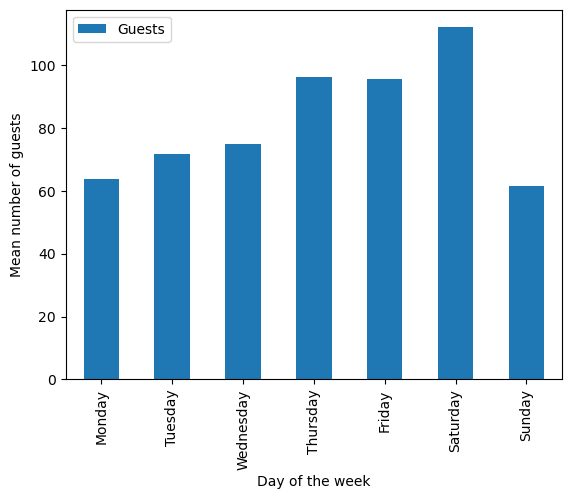

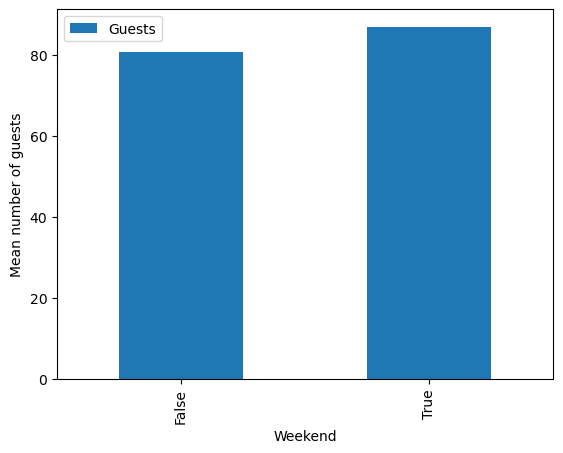

In [7]:
day_of_week_feature = restaurant_df[["DayOfWeek", "Guests"]].groupby("DayOfWeek").mean()
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
day_of_week_feature = day_of_week_feature.reindex(day_order)
day_of_week_feature.plot(
    kind="bar", xlabel="Day of the week", ylabel="Mean number of guests"
)

weekend_feature = restaurant_df[["IsWeekend", "Guests"]].groupby("IsWeekend").mean()
weekend_feature.plot(kind="bar", xlabel="Weekend", ylabel="Mean number of guests")

0.004892627076877569


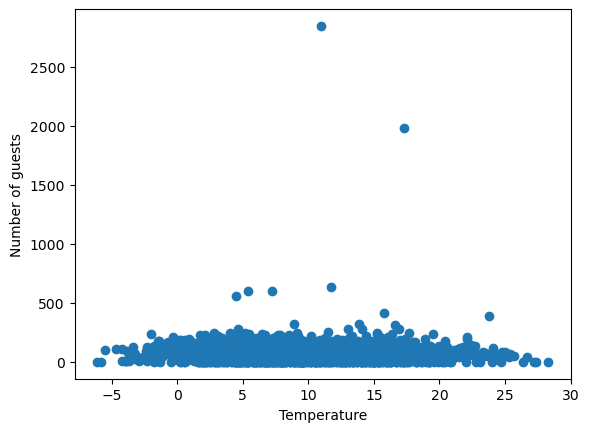

In [8]:
plt.scatter(restaurant_df["temp"], restaurant_df["Guests"])
plt.xlabel("Temperature")
plt.ylabel("Number of guests")
print(restaurant_df["temp"].corr(restaurant_df["Guests"]))

Text(0, 0.5, 'Density')

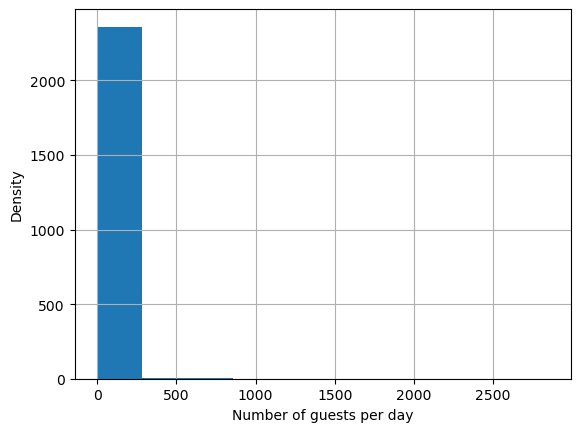

In [9]:
restaurant_df["Guests"].hist()
plt.xlabel("Number of guests per day")
plt.ylabel("Density")

In [10]:
non_numeric = [
    "Date",
    "DayOfWeek",
    "IsWeekend",
    "name",
    "datetime",
    "severerisk",
    "sunrise",
    "sunset",
    "conditions",
    "description",
    "icon",
    "stations",
    "preciptype",
]
numeric_restaurant_df = restaurant_df.drop(non_numeric, axis=1)

numeric_restaurant_df.head(5)

,Guests,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,moonphase
0,0,12.9,7.2,9.5,12.9,4.6,8.0,6.7,83.5,2.532,...,35.0,16.3,135.9,1009.5,21.5,10.7,26.3,2.3,1,0.78
1,0,11.0,1.7,8.2,11.0,-1.1,6.7,5.8,85.6,1.095,...,49.4,22.5,234.3,1017.9,40.6,10.5,25.8,2.2,1,0.81
2,0,10.0,0.6,4.6,10.0,-1.9,2.7,2.8,89.2,0.000,...,30.9,15.5,178.5,1027.0,6.1,8.1,20.3,1.7,1,0.85
3,0,10.7,-0.4,5.2,10.7,-2.5,3.4,3.8,91.3,0.000,...,25.7,13.7,119.7,1017.1,25.9,5.6,24.8,2.0,1,0.89
4,108,10.1,5.9,8.8,10.1,4.3,7.9,7.8,93.7,0.000,...,30.9,15.4,96.0,1009.7,97.1,3.9,13.8,1.1,1,0.92


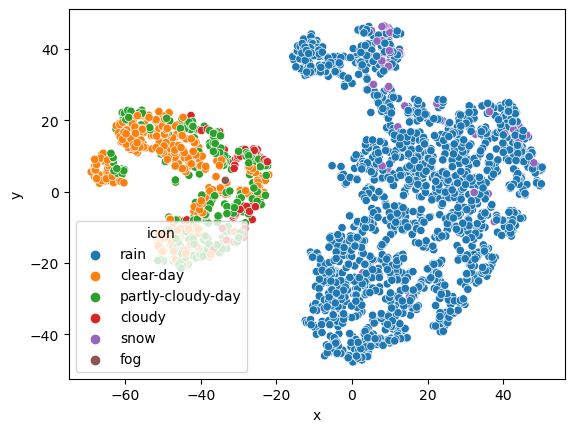

In [11]:
model = TSNE(learning_rate=50)
tsne_features = model.fit_transform(numeric_restaurant_df)
tsne_features[1:4, :]
restaurant_df["x"] = tsne_features[:, 0]
restaurant_df["y"] = tsne_features[:, 1]

sns.scatterplot(x="x", y="y", hue="icon", data=restaurant_df)
plt.show()

In [12]:
restaurant_df.to_csv("../data/out_restaurant.csv", index=False)

In [13]:
filtered_restaurant_df = restaurant_df[restaurant_df["Guests"] != 0]

print((filtered_restaurant_df["Guests"] == 0).sum())

filtered_restaurant_df.shape

0


(2124, 39)

In [14]:
filtered_restaurant_df.to_csv("../data/out_filtered_restaurant.csv", index=False)

In [15]:
menu18_22_df = pd.read_csv("../data/Weeva_data_2018-2022.csv")
menu23_25_df = pd.read_csv("../data/Weeva_Data_2023-x.csv")

menu_df = pd.concat([menu18_22_df, menu23_25_df], ignore_index=True)
menu_df["Date"] = pd.to_datetime(menu_df["Date"], format="%d-%m-%Y")
menu_df.head(20)

,Date,Article,Sold articles amount
0,2018-11-27,Heineken 25cl,31
1,2018-11-27,Chardonnay Glas,4
2,2018-11-27,3 Gang Arrangement,1
3,2018-11-27,Heineken 22cl,2
4,2018-11-27,Schnitzel,8
5,2018-11-27,Sourcy Blauw 20cl,3
6,2018-11-27,Kalmoes Beerenburg,1
7,2018-11-27,Espresso,3
8,2018-11-27,Sauvignon Blanc Glas,14
9,2018-11-27,Stamppot vd dag,3


In [ ]:
# mapping from regex to match article name to standard base menu article name
ArticleConv = {
    "broodplankje": "art_broodplankje",
    "captain.*dinner": "art_captain_dinner",
    "cr.me.*br.l.e": "art_creme_brulee",
    "dame.*blanche": "art_dame_blanche",
    "drie.*sliptongen.*meuni.re": "art_drie_sliptongen_a_la_meuniere",
    "garnalen.*cock": "art_garnalencocktail",
    "groninger.*bloedworst": "art_groninger_bloedworst",
    "huisgemarineerde.*olijven": "art_huisgemarineerde_olijven",
    "kaasplankje": "art_kaasplankje",
    "kalfslever": "art_kalfslever",
    "koffie.*compleet": "art_koffie_compleet",
    "poffert": "art_poffert",
    "runder.*carpaccio": "art_rundercarpaccio",
    "sat.*spies": "art_sate_spies",
    "schnitzel": "art_schnitzel",
    "sorbet.*weeva": "art_sorbet_weeva",
    "stamppot.*andijvie": "art_stamppot_andijvie",
    "vers.*markt": "art_vers_van_de_markt",
    "weeva.*gehaktbal": "art_weeva_gehaktbal",
    "weeva.*spareribs": "art_weeva_spareribs",
    "weeva.*tournedos": "art_weeva_tournedos",
    "zalmfilet": "art_zalmfilet",
}

#TODO: Finish the convension naming and fix the values in the dict

# corrected article name convension
article_convension = {
    "broodplankje": "art_broodplankje",
    "captain.*dinner": "art_captain_dinner",
    "(?<!\w\s)cr.me.*br.l.e(?!\s)": "art_creme_brulee",
    "dame.*blanche(?!\s)": "art_dame_blanche",
    "sliptong.*meuni.re": "art_sliptong",
    "garnalen.*cocktail": "art_garnalen_cocktail",
    "bloedworst": "art_bloedworst",
    "olijven": "art_olijven",
    "kaasplankje(?!\s)": "art_kaasplankje",
    "(?<!\w\s)kalfslever": "art_kalfslever",
    "koffie.*compleet(?!\s)": "art_koffie_compleet",
    "groningse poffert": "art_poffert",
    "runder.*carpaccio": "art_carpaccio",
    "sat.*spies(?!\s)": "art_sate_spies",
    "schnitzel": "art_schnitzel",
    "sorbet.*weeva": "art_sorbet",
    "andijvie stamppot": "art_stamppot",
    "vers.*markt": "art_vers_van_de_markt",
    "weeva.*gehaktbal(?!\s)": "art_gehaktbal",
    "weeva.*spareribs(?!\s)": "art_spareribs",
    "tournedos(?!\s)": "art_tournedos",
    "zalmfilet(?!\s)": "art_zalmfilet",
}

In [17]:
filter = menu_df["Article"].str.lower().str.contains("|".join(list(ArticleConv.keys())))
base_menu_df = menu_df[filter].copy()

base_menu_df["Article"] = [
    [ArticleConv[k] for k in ArticleConv.keys() if bool(re.search(k, art.lower()))][0]
    for art in base_menu_df.Article
]

pivoted_base_menu_df = base_menu_df.pivot_table(
    index="Date",
    columns="Article",
    values="Sold articles amount",
    fill_value=0,
    aggfunc="sum",
)
pivoted_base_menu_df = pivoted_base_menu_df.reset_index()
pivoted_base_menu_df.to_csv("../data/out_pivoted_base_menu.csv", index=False)

In [28]:
pivoted_base_menu_df.head()

Article,Date,art_broodplankje,art_captain_dinner,art_creme_brulee,art_dame_blanche,art_garnalencocktail,art_kaasplankje,art_kalfslever,art_koffie_compleet,art_poffert,art_rundercarpaccio,art_sate_spies,art_schnitzel,art_sorbet_weeva,art_stamppot_andijvie,art_vers_van_de_markt,art_weeva_gehaktbal,art_weeva_spareribs,art_zalmfilet
0,2018-11-27,3,0,0,5,2,0,3,0,5,11,6,8,7,0,0,0,6,2
1,2018-11-28,7,0,7,3,0,2,0,0,3,3,5,3,2,0,0,2,3,5
2,2018-11-29,9,0,10,11,6,1,4,0,3,7,6,8,1,0,0,10,6,6
3,2018-11-30,12,0,5,14,2,0,3,0,6,5,11,10,3,0,0,0,13,3
4,2018-12-01,13,0,5,15,7,2,5,0,8,10,13,10,5,0,0,10,9,8


In [18]:
full_restaurant_df = filtered_restaurant_df.drop(
    ["name", "datetime", "stations", "severerisk", "x", "y", "icon", "description"],
    axis=1,
)
print(filtered_restaurant_df.shape)
print(full_restaurant_df.shape)
full_restaurant_df.head(2)

(2124, 39)
(2124, 31)


,Date,Guests,DayOfWeek,IsWeekend,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,sunrise,sunset,moonphase,conditions
4,2018-11-05,108,Monday,False,10.1,5.9,8.8,10.1,4.3,7.9,...,1009.7,97.1,3.9,13.8,1.1,1,2018-11-05T07:39:14,2018-11-05T16:54:33,0.92,Overcast
5,2018-11-06,99,Tuesday,False,16.6,6.4,10.8,16.6,5.3,10.3,...,1006.2,24.3,6.7,21.6,1.7,1,2018-11-06T07:41:07,2018-11-06T16:52:44,0.96,Partially cloudy


In [19]:
date_ranges = [
    ("2020-03-01", "2020-05-31"),
    ("2020-12-01", "2021-06-30"),
    ("2021-11-01", "2022-01-31"),
]

for start_date, end_date in date_ranges:
    full_restaurant_df = full_restaurant_df[
        ~(
            (full_restaurant_df["Date"] >= start_date)
            & (full_restaurant_df["Date"] <= end_date)
        )
    ]

print(full_restaurant_df.shape)

(1810, 31)


In [20]:
full_restaurant_menu_df = (
    full_restaurant_df.set_index("Date")
    .join(pivoted_base_menu_df.set_index("Date"), how="inner")
    .reset_index()
)
print(full_restaurant_menu_df.shape)

(1785, 49)


In [21]:
def multi_value_one_hot_handle_nan(df, column_to_split, prefix=""):
    splitted = []
    for index, value in df[column_to_split].items():
        if pd.isna(value):
            splitted.append([])
        else:
            items = [item.strip() for item in str(value).split(",")]
            splitted.append(items)

    df_splitted = pd.Series(splitted, index=df.index)
    unique_values = df_splitted.explode().unique()

    for val in unique_values:
        if pd.isna(val):
            continue
        df[f"{ prefix }{ val }".lower().replace(" ", "_")] = df_splitted.apply(lambda x: 1 if val in x else 0)

    return df

In [22]:
full_restaurant_menu_enc_df = full_restaurant_menu_df.copy()
full_restaurant_menu_enc_df["IsWeekend"] = full_restaurant_menu_enc_df[
    "IsWeekend"
].astype(int)

one_hot = pd.get_dummies(full_restaurant_menu_df["DayOfWeek"].str.lower(), prefix="day", dtype=int)
full_restaurant_menu_enc_df = full_restaurant_menu_enc_df.join(one_hot)

multi_value_one_hot_handle_nan(full_restaurant_menu_enc_df, "preciptype", "prec_")
multi_value_one_hot_handle_nan(full_restaurant_menu_enc_df, "conditions", "cond_")

full_restaurant_menu_enc_df = full_restaurant_menu_enc_df.drop(
    ["DayOfWeek", "preciptype", "conditions"], axis=1
)

full_restaurant_menu_enc_df["sunrise"] = pd.to_datetime(full_restaurant_menu_enc_df["sunrise"])
full_restaurant_menu_enc_df["sunset"] = pd.to_datetime(full_restaurant_menu_enc_df["sunset"])

In [25]:
# full_restaurant_menu_enc_df.to_csv(
    # "../data/out_full_restaurant_menu_excl_covid.csv", index=False
# )

full_restaurant_menu_enc_df.columns



Index(['Date', 'Guests', 'IsWeekend', 'tempmax', 'tempmin', 'temp',
       'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity',
       'precip', 'precipprob', 'precipcover', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'sunrise', 'sunset',
       'moonphase', 'art_broodplankje', 'art_captain_dinner',
       'art_creme_brulee', 'art_dame_blanche', 'art_garnalencocktail',
       'art_kaasplankje', 'art_kalfslever', 'art_koffie_compleet',
       'art_poffert', 'art_rundercarpaccio', 'art_sate_spies', 'art_schnitzel',
       'art_sorbet_weeva', 'art_stamppot_andijvie', 'art_vers_van_de_markt',
       'art_weeva_gehaktbal', 'art_weeva_spareribs', 'art_zalmfilet',
       'day_friday', 'day_monday', 'day_saturday', 'day_sunday',
       'day_thursday', 'day_tuesday', 'day_wednesday', 'prec_rain',
       'prec_snow', 'cond_rain', 'cond_partially_cloudy', 'cond_snow',
